In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
df = pd.read_csv('E:/smartcart_clustering_system/data/smartcart_customers.csv')  # Load your dataset here

In [14]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [15]:
df.shape

(2240, 22)

In [16]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# Data Preprocessing
### 1 handle missing values

In [17]:
df['Income'] = df['Income'].fillna(df['Income'].median())# why we can not fill income with mean value because the mean is sensitive to outliers, which can skew the data. The median is a better measure of central tendency for skewed distributions, as it is less affected by extreme values.

In [18]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


# Feature Engineering

In [19]:
# getting age

df["Age"] = 2026 - df["Year_Birth"]
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,88,3,8,10,4,7,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,6,2,1,1,2,5,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,21,42,1,8,2,10,4,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,3,5,2,2,0,4,6,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,27,15,5,5,3,6,5,0,0,45


In [20]:
# Customer joing date
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)

refrence_date = df["Dt_Customer"].max()

df["Customer_Tenure_Days"] = (refrence_date - df["Dt_Customer"]).dt.days

In [21]:
df.head()  # Display the first few rows of the dataset

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


In [22]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days'],
      dtype='str')

In [23]:
# Spending  new feature =  total _spending

df["Total_Spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

In [24]:
# children

df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [25]:
# education

print(df["Education"].value_counts())

# UnderGraduate, Graduate, PostGraduate

df["Education"] = df["Education"].replace({"Basic": "UnderGraduate", "2n Cycle": "UnderGraduate", "Master": "PostGraduate", "PhD": "PostGraduate"})

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64


In [26]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,1
4,5324,1981,PostGraduate,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,1


In [27]:
# handling martial status

df["Living_With"] = df["Marital_Status"].replace({
    "Married": "Partner",
    "Together": "Partner",
    "Single": "Alone",
    "Divorced": "Alone",
    "Absurd": "Alone",
    "YOLO": "Alone",
    "Widow": "Alone"
})

In [28]:
df["Living_With"].value_counts()

Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

## Drop Columns

In [29]:
df.shape
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663,1617,0,Alone
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113,27,2,Alone
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312,776,0,Partner
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139,53,1,Partner
4,5324,1981,PostGraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161,422,1,Partner


In [30]:
cols = ["ID", "Year_Birth", "Dt_Customer", "Marital_Status","Kidhome", "Teenhome"]

spending_cols = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]

cols_to_drop = cols + spending_cols

df_cleaned =df.drop(columns=cols_to_drop)

In [31]:
df_cleaned.shape
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,Graduation,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduation,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduation,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduation,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,PostGraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


# Handling outliers

#### the pair plot is a great way to visualize the relationships between multiple variables in a dataset. It creates scatter plots for each pair of variables and histograms for each individual variable, allowing you to see potential correlations, distributions, and patterns in the data. 

##### detecting outliers in data becomes more easier using pair plot

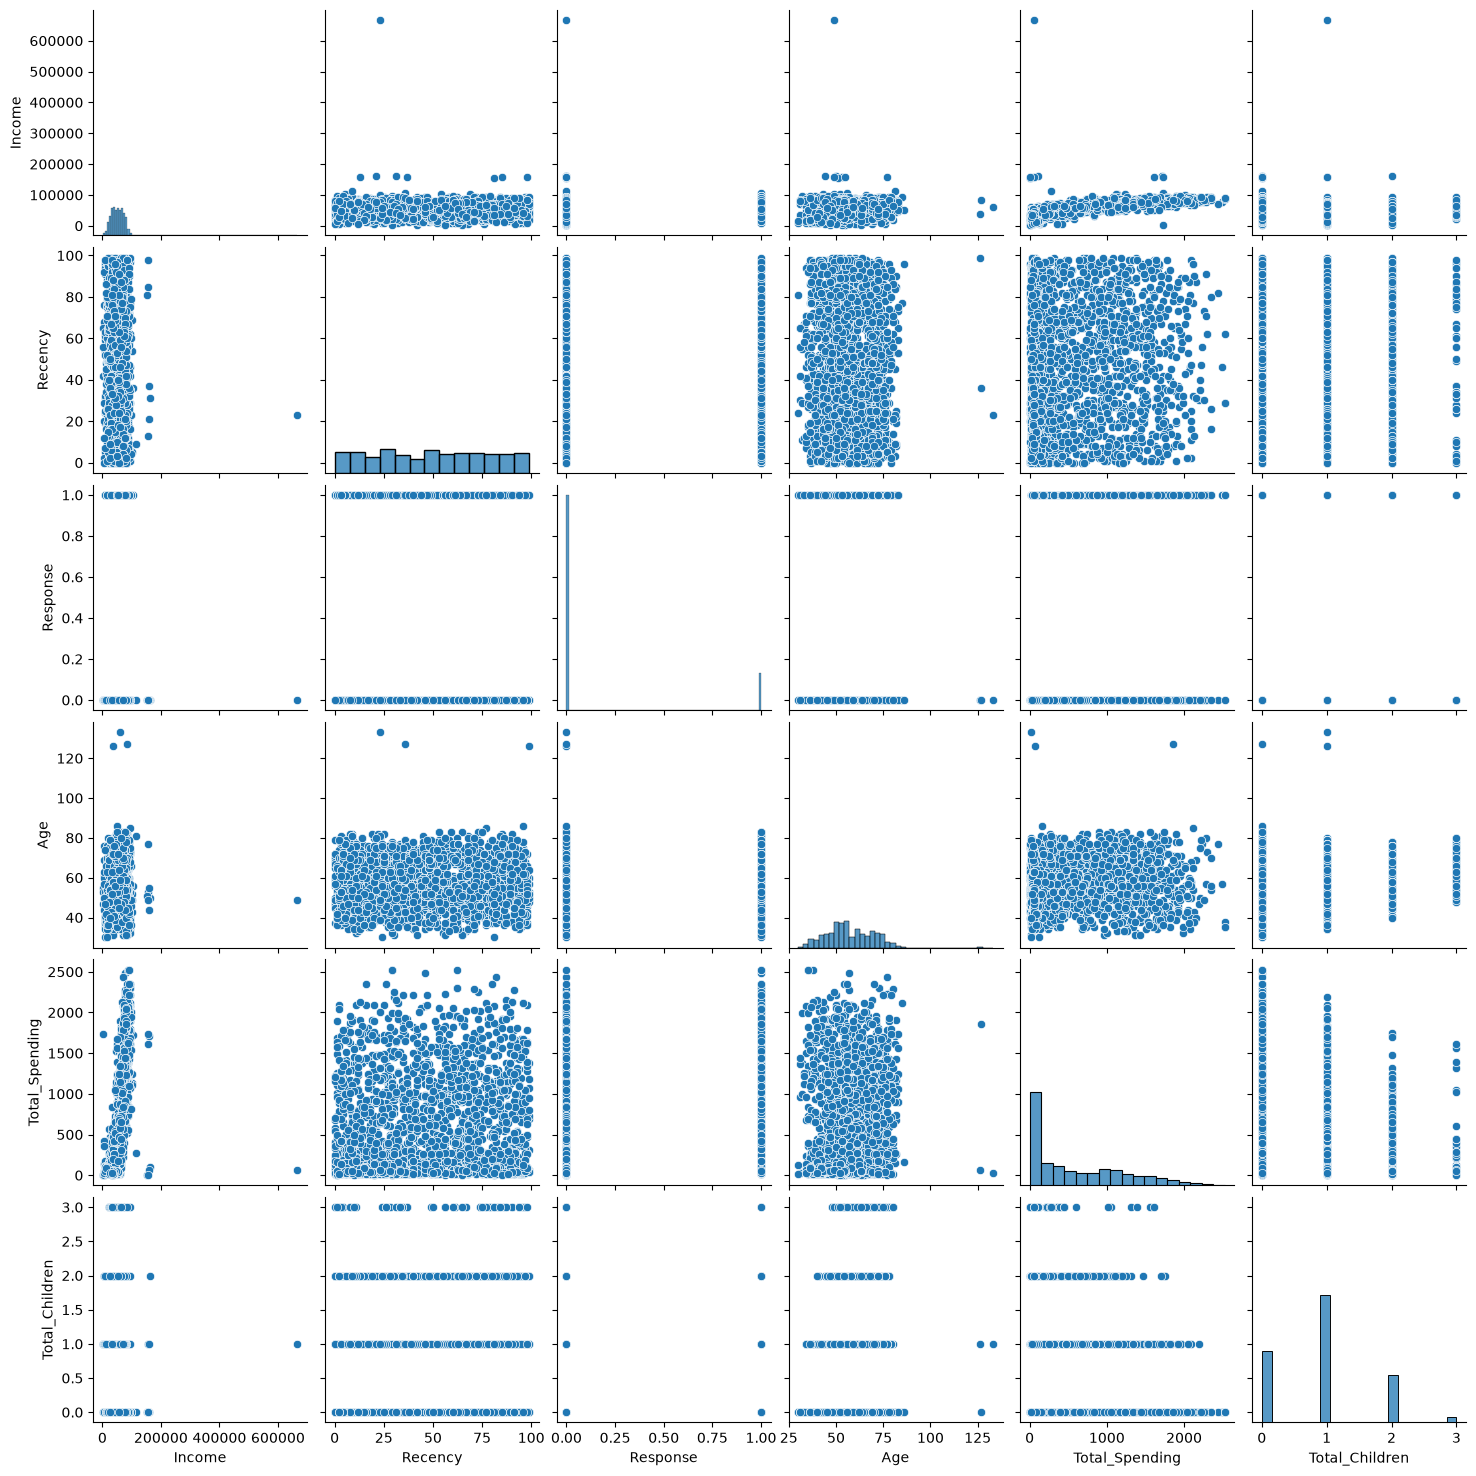

In [32]:
cols = ["Income","Recency","Response","Age","Total_Spending","Total_Children"]

# relative plots of some features = pair plots

sns.pairplot(df_cleaned[cols]) # the pair plot is a great way to visualize the relationships between multiple variables in a dataset. It creates scatter plots for each pair of variables and histograms for each individual variable, allowing you to see potential correlations, distributions, and patterns in the data. 



In [33]:
# remove outliers

print("data size with outliers:", len(df_cleaned))

df_cleaned = df_cleaned[(df_cleaned["Age"] < 90)]
df_cleaned = df_cleaned[(df_cleaned["Income"] < 600_000)]

print("data size without outliers:", len(df_cleaned))

data size with outliers: 2240
data size without outliers: 2236


# HeatMap

<Axes: >

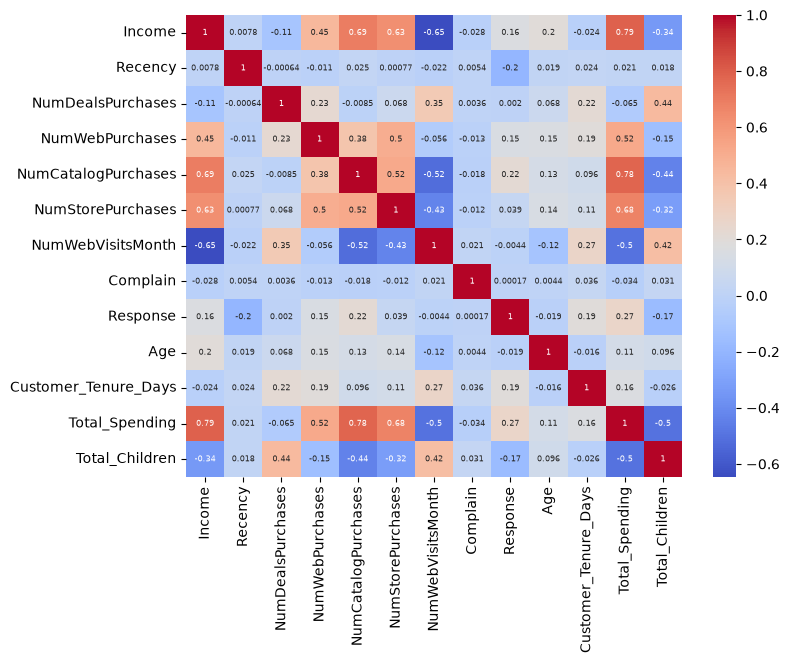

In [34]:
corr_mat = df_cleaned.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_mat, 
    annot=True,
    annot_kws={"size": 6}, # reduces the size of the annotation text in the heatmap for better readability
    cmap="coolwarm"
    )

In [35]:
df_cleaned.shape
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,Graduation,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduation,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduation,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduation,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,PostGraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


# Encoding  = one hot encoding

In [36]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [37]:
ohe = OneHotEncoder()

cat_cols = ["Education", "Living_With"]

enc_cols = ohe.fit_transform(df_cleaned[cat_cols]).toarray() 

In [38]:
enc_df = pd.DataFrame(enc_cols,columns = ohe.get_feature_names_out(cat_cols),index=df_cleaned.index)  

enc_df.head()

,Education_Graduation,Education_PostGraduate,Education_UnderGraduate,Living_With_Alone,Living_With_Partner
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0


In [39]:
df_cleaned = df_cleaned.drop(columns=cat_cols)

df_encoded = pd.concat([df_cleaned, enc_df], axis=1)

In [40]:
df_encoded.shape
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduation,Education_PostGraduate,Education_UnderGraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


# Scaling

In [41]:
X = df_encoded

In [42]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## Visualization

In [43]:
X_scaled.shape

(2236, 18)

In [44]:
#2d
from sklearn.decomposition import PCA

pca = PCA(n_components=3)

X_pca = pca.fit_transform(X_scaled)


In [45]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0.92, '3D PCA Scatter Plot')

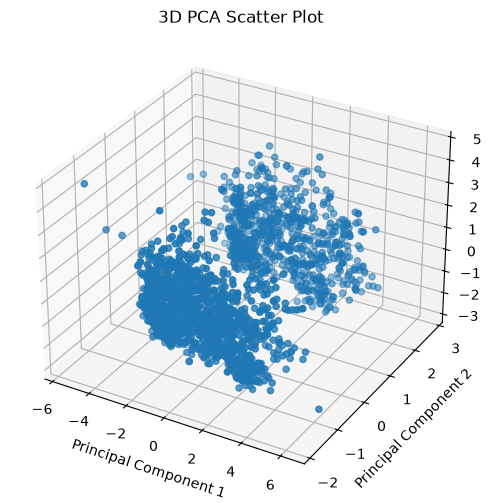

In [46]:
#plot
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2])

ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')
ax.set_title('3D PCA Scatter Plot')

### finding the perfect value of k using elbow method and silhoutte score

In [47]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss= []

for k in range(1,11):
    kmeans = KMeans(n_clusters=k,  random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [48]:
knee = KneeLocator(range(1,11),wcss,curve = "convex", direction = "decreasing")

optimal_k = knee.elbow

print("best k ", optimal_k)

best k  4


Text(0, 0.5, 'wcss')

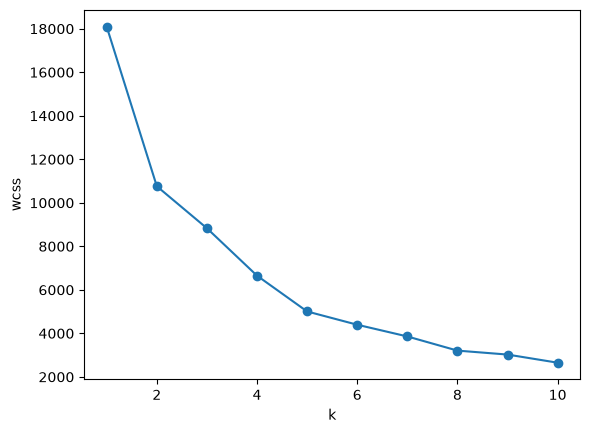

In [49]:
# plot

plt.plot(range(1,11), wcss, marker = 'o')
plt.xlabel("k")
plt.ylabel("wcss")

## Silhouette Score

In [50]:
from sklearn.metrics import silhouette_score
scores = []

for k in range(2,11):
    kmeans = KMeans(n_clusters = k, random_state = 42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca,labels)
    scores.append(score)

Text(0, 0.5, 'Silhouette')

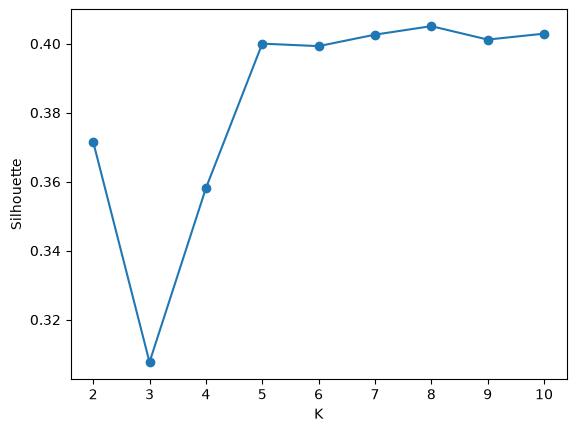

In [51]:
#plot

plt.plot(range(2,11),scores, marker ='o')
plt.xlabel("K")
plt.ylabel("Silhouette")

Text(0, 0.5, 'Silhouette')

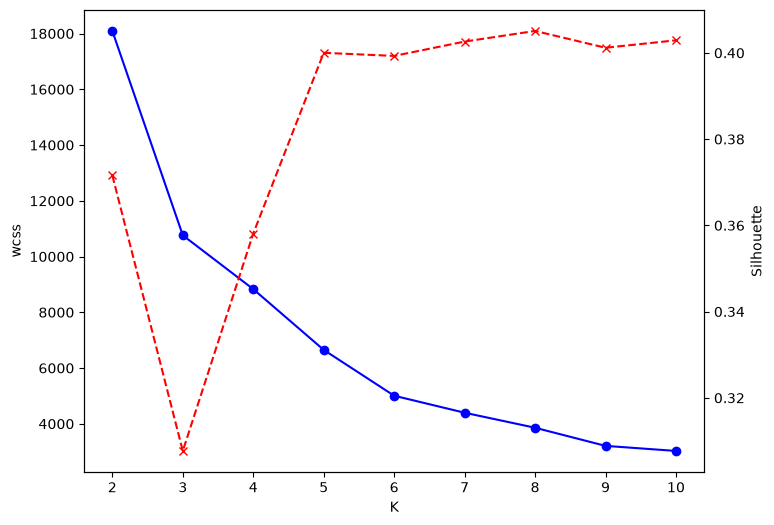

In [52]:
# combined plot for both

k_range = range(2,11)

fig,ax1 = plt.subplots(figsize= (8,6))

ax1.plot(k_range, wcss[:len(k_range)],marker = 'o', color = "blue")
ax1.set_xlabel("K")
ax1.set_ylabel("wcss")

ax2 = ax1.twinx()

ax2.plot(k_range, scores[:len(k_range)], marker="x", color="red", linestyle="--")

ax2.set_xlabel("k")
ax2.set_ylabel("Silhouette")

In [53]:
# kmeans

kmeans = KMeans(
    n_clusters = 4,
    random_state=42
)

labels_mean = kmeans.fit_predict(X_pca)

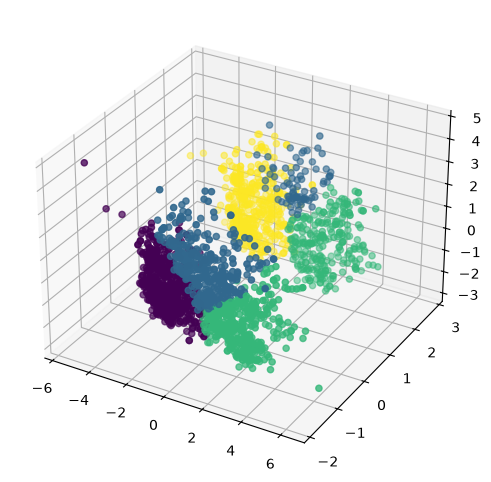

In [54]:
fig = plt.figure(figsize=(10, 6))

ax = fig.add_subplot(111, projection='3d') # 111 means 1 row, 1 column, 1st subplot other values we have 221 means 2 rows, 2 columns, 1st subplot and so on

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_mean)

In [55]:
# agglomerative clustering

from sklearn.cluster import AgglomerativeClustering

agg_cls = AgglomerativeClustering(
    n_clusters=4,
    # affinity='euclidean', # distance metric to use for clustering
    linkage='ward' # linkage method to minimize the variance of merged clusters. ward means that it minimizes the total within-cluster variance. At each step, the pair of clusters with the smallest increase in total within-cluster variance after merging is combined
)

labels_agg = agg_cls.fit_predict(X_pca)

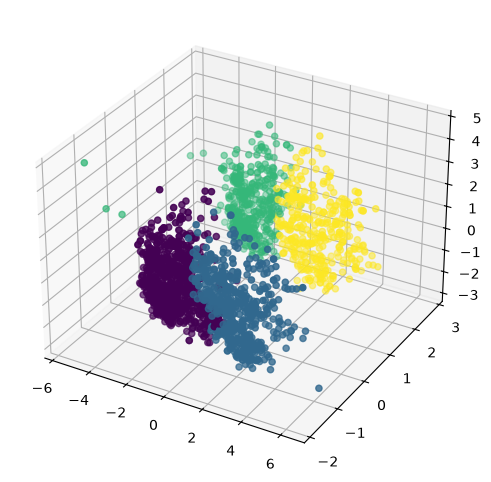

In [56]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_agg)


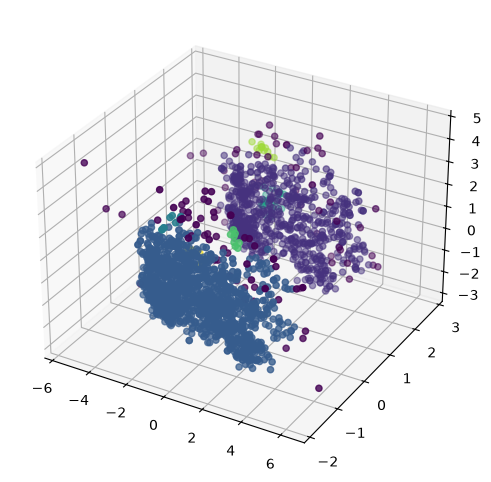

In [57]:
 # using db scan for clustering
 
from sklearn.cluster import DBSCAN
 
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_pca)

# plotting the dbscan clusters

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_dbscan)
 

## Characterization of Characters

In [58]:
X["clusters"] = labels_agg


In [59]:
X.head()


,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduation,Education_PostGraduate,Education_UnderGraduate,Living_With_Alone,Living_With_Partner,clusters
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='clusters', ylabel='count'>

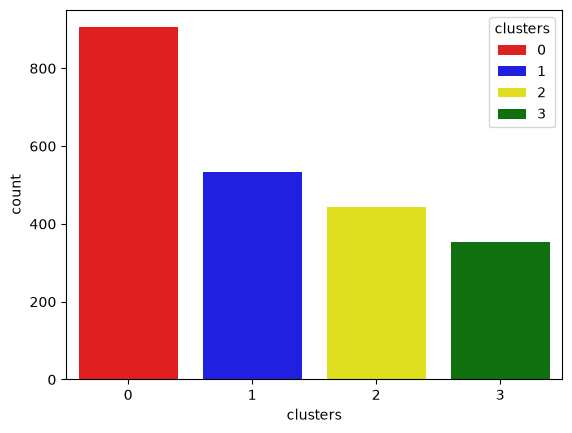

In [60]:
pal = ["red", "blue", "yellow", "green"]

sns.countplot(x=X["clusters"], palette=pal, hue = X["clusters"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

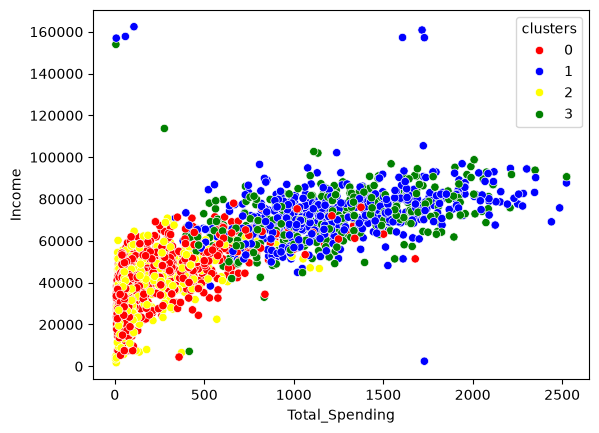

In [61]:
# income & spending patterns

sns.scatterplot(x=X["Total_Spending"], y=X["Income"], hue=X["clusters"], palette=pal)

# Customers profiling

## based on clusters


### 1 red: income - low/moderate income,   spending - low/moderate spending

### 2 blue : income - high income,   spending - high spending

### 3 yellow : income - low income, spending - low spending

### 4 green  : income - moderate/high income, spending - high spending

# Cluster summary

In [62]:
cluster_summary = X.groupby("clusters").mean()

print(cluster_summary)

                Income    Recency  NumDealsPurchases  NumWebPurchases  \
clusters                                                                
0         39680.580110  48.914917           2.594475         3.153591   
1         72808.445693  49.202247           1.958801         5.687266   
2         36960.143018  48.319820           2.594595         2.713964   
3         70722.681303  50.504249           1.855524         5.790368   

          NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
clusters                                                                        
0                    0.969061           4.143646           6.307182  0.011050   
1                    5.498127           8.659176           3.580524  0.005618   
2                    0.837838           3.623874           6.659910  0.011261   
3                    5.014164           8.430595           3.728045  0.005666   

          Response        Age  Customer_Tenure_Days  Total_Spending  \
clu